# S9-5 バックテスト基盤と戦略評価

## 学習目標

- ルックアヘッド（look-ahead）のない債券戦略バックテスターを、シグナルと
  リターンから自分で組み立てられる
- 債券バックテスト特有の罠（ロール処理・経過利子・データのポイントインタイム性）
  を列挙し、実装上どこで事故が起きるかを説明できる
- 評価指標（シャープレシオ・最大ドローダウン・回転率）を定義から計算できる
- 取引コストを回転率に比例させたコストモデルを組み込み、コスト感応度を分析できる
- 「未来のカーブを使うバグ」を lag=0 と lag=1 の差として数値で観測し、
  ルックアヘッド検査の型を身につける

本 notebook は S9-1〜9-4 で作った相対価値シグナル（rich/cheap 平均回帰と
バタフライ）を統合し、`bondlab.bt` を土台に評価まで通す最終回です。

## 実務での位置づけ（ファンドはどう稼ぐか）

バックテスト基盤は、S9-1〜9-4 で作った相対価値シグナル（rich/cheap の平均回帰、バタフライの曲率、先物ベーシス）を実弾を張る前にふるいにかける最終工程です。RV ファンドが取りにいく歪みは1トレードあたり数 bp と薄く、レバレッジとレポで名目を膨らませて初めて意味のある収益になります。裏を返せば、シグナルの本当のエッジがわずかでも過大評価されていれば、レバレッジがそれを増幅して大きな損失に化けます。だからこそ、過去データ上で「このシグナルに賭ける価値が本当にあるか」を忠実に再現することが、資本を守る作業そのものになります。

ルックアヘッドバイアスの検査は、バックテストが収益を守る中核です。$t$ 日終値で計算したシグナルで同じ日の値動きを取りにいく（lag=0）と、物理的にあり得ない売買を再現してしまい、成績は現実と別物になります。特に平均回帰戦略では「今まさに割安になった＝直前に負けた」銘柄を買うため、同時点評価は真の成績を系統的に歪めます。lag=0 と lag=1 の差を数値で観測してエッジがどれだけ幻だったかを突き止めることは、レバレッジをかける前に必ず通すべき関門です。ここを省いて過大評価されたシャープレシオに資金を張れば、実運用でエッジが蒸発し、レバレッジぶんだけ損失が拡大します。

債券特有の三つの罠——ロール処理・経過利子・ポイントインタイム性——は、いずれも「現実には知り得なかった情報や偽の損益」を紛れ込ませて成績を歪めます。満期到来銘柄の前方補完が偽のジャンプを生み、クリーン価格だけで組めばキャリーを取りこぼし、公表遅れのデータをその日の値として使えば実質ルックアヘッドになります。これらを潰さないバックテストは、実際には取れない収益を成績に計上するので、運用に移した瞬間に乖離します。

取引コストを回転率に比例させて組み込み、コスト感応度を分析する工程は、薄いエッジのシグナルにとって死活的です。数 bp の歪みを取る戦略は、回転率が上がるとビッド・オファーとレポコストにエッジを食い尽くされます。コスト前で魅力的でもコスト後に消えるシグナルは実運用では稼げないので、コスト感応度は「どの回転率まで張れるか」「そもそも実弾に値するか」を決める最終判断になります。バックテストを通すとは、机上のアルファを実際に手元に残る収益へと翻訳し、レバレッジで増幅してよい戦略だけを選別することにほかなりません。


## 理論

### バックテストとは何を近似しているか

バックテスト（backtest）は、過去データ上で戦略を仮想的に売買し、実現していたで
あろう損益を再現する手続きです。目的は「この戦略に賭ける価値があるか」を、
実弾を張る前に見積もることにあります。したがって再現の忠実さがすべてで、
現実には知り得なかった情報を1ビットでも混ぜれば、成績は上振れし判断を誤ります。

損益の骨格は次の一本の式に集約されます。$t$ 日の各資産のポジションを $w_{t}$、
その日のリターンを $r_{t}$ とすると、

$$ \text{PnL}_t = \sum_i w_{i,t}\, r_{i,t} \;-\; c \sum_i \lvert w_{i,t} - w_{i,t-1} \rvert. $$

第1項が総損益（グロス）、第2項が取引コストです。ここで決定的に重要なのは
**$w_{i,t}$ がいつの情報で決まるか**です。$t$ 日のリターン $r_{i,t}$ は
$t-1$ 日終値から $t$ 日終値への変化ですから、その区間を取りにいくポジションは
遅くとも $t-1$ 日の終値時点までの情報で確定していなければなりません。

### ルックアヘッドバイアス（look-ahead bias）

シグナルを $s_t$（$t$ 日までの情報で計算）とするとき、正しい約定は

$$ w_t = s_{t-1} \quad (\text{lag}=1,\ \text{翌営業日約定}) $$

です。もし $w_t = s_t$（lag=0）としてしまうと、$t$ 日終値で計算したシグナルで
$t-1 \to t$ の値動きを取りにいくことになり、**同じ日の終値を「見てから」その日
の値動きを取る**という物理的にあり得ない売買になります。これがルックアヘッド
バイアスです。

混入の効果は「過大」の一方向とは限りません。シグナルが当期リターン $r_{i,t}$ と
**正に相関**する場合（トレンド追随や、当期の値動きを覗き見たシグナル）は成績が
**過大評価**されます。一方、平均回帰では「今まさに割安になった＝直前に
アンダーパフォームした」銘柄を買うため、当期リターンと符号が逆になり、同時点評価は
逆に成績を崩します。いずれにせよ真の成績とは**別物**になります。本 notebook では、
（1）当期リターンを覗き見たシグナルで**過大評価**が起きる例と、（2）平均回帰戦略で
lag=1 と lag=0 が大きく食い違う例の両方を、数値で示します。

### 債券バックテスト特有の三つの罠

| 罠 | 内容 | 事故の起き方 |
|---|---|---|
| ロール処理（roll） | 残存年限は日々短くなり、ベンチマーク銘柄は入替わる。銘柄を固定して価格をつなぐと、償還・銘柄切替の断層がリターンに紛れる | 満期到来銘柄のリターンが欠損→前方補完で偽のジャンプ |
| 経過利子（accrued interest） | 債券のトータルリターンは値幅だけでなく日々積み上がる経過利子を含む。クリーン価格だけで損益を組むとキャリーを取りこぼす | クーポン受渡日にダーティ価格が不連続→負のリターンに誤認 |
| ポイントインタイム性（point-in-time） | 各日に「その日に本当に見えていた値」だけを使う。改定値・遡及修正値・確定前のカーブを使うと未来が混入する | 公表遅れのデータをその日の値として使い、実質ルックアヘッド |

本 notebook のバックテスターは、これらのうち **ポイントインタイム性**（lag による
約定タイミングの制御）に焦点を当てます。ロールと経過利子は、入力となるリターン系列
$r_{i,t}$ を作る段階で処理すべき論点で、ここでは「相対リターンを DV01 中立で組む」
前提により副次的に切り離しています。

### サバイバーシップバイアス（survivorship bias）

ロールと表裏一体なのがサバイバーシップバイアス（survivorship bias）です。
償還・デフォルト・指数除外で消えた銘柄を分析対象から落とすと、生き残った
銘柄だけで戦略を評価してしまい、成績が上振れします。債券は満期があるため
株式より深刻で、「現在の構成銘柄で過去を再現する」実装は典型的な混入経路です。
正しくは、各時点の「当時の投資対象集合」を再構成します。

### 評価指標

| 指標 | 定義 | 意味 |
|---|---|---|
| シャープレシオ（Sharpe ratio） | $\sqrt{P}\,\bar{r}/\sigma_r$（$P$=年間営業日数） | リスク1単位あたりの超過リターン |
| 最大ドローダウン（maximum drawdown） | $\min_t\big(E_t - \max_{u\le t} E_u\big)$、$E_t=\sum_{u\le t} \text{PnL}_u$ | 累積損益が高値からどれだけ落ちたかの最悪値 |
| 回転率（turnover） | $\sum_i \lvert w_{i,t}-w_{i,t-1}\rvert$ | ポジション入替の量。コストの源泉 |
| ヒット率（hit rate） | $\Pr(\text{PnL}_t > 0)$ | 勝ち日の割合 |

### 取引コストモデル

本 notebook では、片道コストを回転率に比例させる線形モデルを使います。片道
$c$ ベーシスポイント（bp）なら、$t$ 日のコストは $c\cdot 10^{-4}\cdot\sum_i
\lvert w_{i,t}-w_{i,t-1}\rvert$ です。ビッド・アスク・スプレッドや
マーケットインパクトの一次近似で、コストを振ってシャープの感応度を見るには十分です。

### 過剰適合（overfitting）

バックテストの本質的な危うさは、探索の自由度が高いほど良い成績が**偶然**
出てしまう点にあります。パラメータ（回帰窓・zスコア閾値・銘柄バケット）を
成績が良くなるまで動かせば、ノイズに当てはめた戦略が出来上がります。
対策は、パラメータを事前に固定し、期間分割（学習/検証）で確認し、
コストと現実的な約定遅延を必ず入れて評価することです。本 notebook では
パラメータを最初に決め打ちし、コスト感応度と lag 感応度で頑健性を点検します。

**数値例**：日次PnLが $(+0.5,+0.3,-0.4,-0.6,-0.2,+0.7)$ のとき累積損益は $E_t=(0.5,0.8,0.4,-0.2,-0.4,0.3)$。過去高値 $0.8$ からの落ち込みが最大となる5日目で $\min_t(E_t-\max_{u\le t}E_u)=-0.4-0.8=-1.2$ が最大ドローダウンです。


**数値例**：日次PnLの平均 $\bar r=0.02$、標準偏差 $\sigma_r=0.15$、年間営業日 $P=252$ なら シャープレシオ $=\sqrt{252}\times0.02/0.15\approx2.12$ となります。


## スクラッチ実装

バックテスターを numpy/pandas で自作します。まず入力（シグナルとリターン）を
作り、次に損益エンジンと評価指標を実装します。設計方針は「シグナルは1期
ずらして約定（既定 lag=1）」「コストは回転率に比例」で、`bondlab.bt` と
完全一致することを後段で確認します。

### 使用する自作関数

| 関数 | 引数 | 返り値 | 役割 |
|---|---|---|---|
| `load_yield_panel(path)` | csv パス | (Y, dur) | 利回りパネルを日付×銘柄に整形し、年限も返す |
| `cross_section_residuals(Y, mat, degree)` | 利回り, 年限, 多項式次数 | 残差 DataFrame | 各日にカーブを当て、rich/cheap 残差を求める |
| `zscore_signal(resid)` | 残差 | シグナル DataFrame | 断面 z スコアで平均回帰シグナルを作る |
| `relative_returns(resid, dur)` | 残差, 年限 | リターン DataFrame | $-D\,\Delta(\text{残差})$ を相対リターンとする |
| `butterfly_series(Y, mat)` | 利回り, 年限 | (signal, return) | 2-5-10 バタフライのシグナルとリターン |
| `my_backtest(signals, returns, cost_bps, lag)` | シグナル, リターン, コスト, ラグ | dict | 損益エンジン（`bondlab.bt.backtest` の自作版） |
| `my_performance(pnl, periods_per_year)` | 損益, 年間期数 | dict | 評価指標（`bondlab.bt.performance` の自作版） |

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
import bondlab
from bondlab import bt

np.random.seed(0)
print("bondlab version:", bondlab.__version__)

# リポジトリ直下からの相対パスでデータを読む（絶対パスは使わない）。
DATA = Path("data/samples/synthetic_jgb_yield_panel.csv")
if not DATA.exists():
    # notebook をサブフォルダから実行した場合に備え、2階層上まで遡って探す。
    for up in (Path(".."), Path("../..")):
        if (up / DATA).exists():
            DATA = up / DATA
            break
print("データ:", DATA)

bondlab version: 0.0.1
データ: data/samples/synthetic_jgb_yield_panel.csv


In [2]:
def load_yield_panel(path):
    """利回りパネル CSV を日付×銘柄の行列に整形する。

    返り値 Y は index=日付・columns=銘柄・値=利回り。dur は銘柄ごとの
    残存年限（修正デュレーションの代理）。
    """
    raw = pd.read_csv(path, parse_dates=["date"])
    Y = raw.pivot(index="date", columns="bond_id", values="yield").sort_index()
    mat = raw.groupby("bond_id")["maturity_years"].mean().reindex(Y.columns)
    return Y, mat


Y, mat = load_yield_panel(DATA)
print("パネル形状 (日付, 銘柄):", Y.shape)
print("年限レンジ: {:.1f} 〜 {:.1f} 年".format(mat.min(), mat.max()))

パネル形状 (日付, 銘柄): (60, 40)
年限レンジ: 1.3 〜 29.4 年


### rich/cheap 残差シグナル

各日に「利回り対年限」のカーブ（3次多項式）を最小二乗で当て、実測利回りから
フィット値を引いた残差を rich/cheap の指標とします。残差が正（カーブより高利回り）
なら価格が割安（cheap）、負なら割高（rich）です。平均回帰の賭けは「残差はいずれ
0 へ戻る」ですから、cheap（残差正）を買い、rich（残差負）を売るように、断面の
z スコアをそのままポジションにします。

In [3]:
def cross_section_residuals(Y, mat, degree=3):
    """各日に利回り対年限のカーブを当て、rich/cheap 残差を返す。

    残差 > 0：カーブより高利回り = 価格が割安（cheap）。
    残差 < 0：カーブより低利回り = 価格が割高（rich）。
    """
    x = mat.values.astype(float)
    resid = pd.DataFrame(index=Y.index, columns=Y.columns, dtype=float)
    for d, row in Y.iterrows():
        y = row.values.astype(float)
        coef = np.polyfit(x, y, degree)      # その日の断面だけで係数を推定
        fit = np.polyval(coef, x)
        resid.loc[d] = y - fit
    return resid


def zscore_signal(resid):
    """残差を断面（各日・銘柄横断）で z スコア化し、平均回帰シグナルにする。

    各日で銘柄平均0・分散1に正規化するため、ポジションは自動的にほぼ
    ダラー中立（買いと売りが釣り合う）になる。
    """
    mu = resid.mean(axis=1)
    sd = resid.std(axis=1, ddof=0).replace(0.0, np.nan)
    z = resid.sub(mu, axis=0).div(sd, axis=0)
    return z.fillna(0.0)


def relative_returns(resid, dur):
    """相対価値ポジションの日次リターンを $-D\\,\\Delta(\\text{残差})$ で近似する。

    価格リターン ≈ -修正デュレーション × 利回り変化。ここでは「カーブに対する
    相対的な利回り変化」= 残差の変化を使う。DV01 中立の相対トレードを想定。
    """
    d_resid = resid.diff()
    return -d_resid.mul(dur, axis=1)


resid = cross_section_residuals(Y, mat, degree=3)
sig_rv = zscore_signal(resid)
ret_rv = relative_returns(resid, mat)

print("残差の平均振れ幅: {:.1f} bp".format(resid.abs().mean().mean() * 1e4))
print("シグナルの範囲: {:.2f} 〜 {:.2f}".format(sig_rv.min().min(), sig_rv.max().max()))

残差の平均振れ幅: 4.8 bp
シグナルの範囲: -2.53 〜 2.17


### バタフライ戦略

2-5-10 バタフライは、短中長の3年限を組んでカーブの曲率（belly の割高・割安）に
賭けるトレードです。fly $= y_{5} - \tfrac{1}{2}(y_{2}+y_{10})$ を各日に計算し、
その z スコア（時系列）で平均回帰を狙います。fly が高い（belly が割高）なら
belly 売り・wings 買いになるよう、シグナルの符号を取ります。

In [4]:
def butterfly_series(Y, mat, wings=(2.0, 10.0), belly=5.0):
    """2-5-10 バタフライのシグナルとリターンを作る。

    各バケットに最も近い年限の銘柄を代表に選び、fly = belly - 0.5*(short+long)。
    シグナルは fly の時系列 z スコアの符号反転（高い fly = belly 売り）。
    リターンは -Δfly（fly が縮むと belly 売りが儲かる）。
    """
    def nearest(target):
        return (mat - target).abs().idxmin()

    s, b, l = nearest(wings[0]), nearest(belly), nearest(wings[1])
    fly = Y[b] - 0.5 * (Y[s] + Y[l])
    z = (fly - fly.mean()) / fly.std(ddof=0)
    signal = (-z).rename("FLY")            # fly が高い→belly売り（負ポジ）
    ret = (-fly.diff() * mat[b]).rename("FLY")
    return signal.to_frame(), ret.to_frame(), (s, b, l)


sig_fly, ret_fly, fly_bonds = butterfly_series(Y, mat)
print("バタフライ代表銘柄 (short, belly, long):", fly_bonds)
print("年限: {:.1f} / {:.1f} / {:.1f} 年".format(*[mat[b] for b in fly_bonds]))

バタフライ代表銘柄 (short, belly, long): ('JGB001', 'JGB008', 'JGB015')
年限: 2.6 / 4.9 / 10.9 年


### 損益エンジンと評価指標の自作

`bondlab.bt.backtest` / `performance` と同じ規約で、損益エンジンと評価指標を
自作します。ポジションは `shift(lag)` で約定を遅らせ、コストは回転率に比例、
最初の lag 日はポジション0です。

In [5]:
def my_backtest(signals, returns, cost_bps=0.0, lag=1):
    """シグナルとリターンから日次損益を計算する（bondlab.bt.backtest の自作版）。

    lag 日ずらして約定（既定 1 = 翌営業日）。コストは回転率（ポジション変化の
    絶対値の合計）に片道 cost_bps を掛ける。
    """
    sig = signals if isinstance(signals, pd.DataFrame) else signals.to_frame()
    ret = returns if isinstance(returns, pd.DataFrame) else returns.to_frame()
    ret = ret.reindex_like(sig)
    positions = sig.shift(lag).fillna(0.0)
    gross = (positions * ret).sum(axis=1)
    turnover = positions.diff().abs().sum(axis=1).fillna(positions.abs().sum(axis=1))
    cost = turnover * (cost_bps * 1e-4)
    pnl = gross - cost
    return dict(pnl=pnl, positions=positions, gross_pnl=gross, cost=cost, turnover=turnover)


def my_performance(pnl, periods_per_year=252):
    """損益系列の評価指標（bondlab.bt.performance の自作版）。"""
    pnl = pd.Series(pnl).dropna()
    mean = pnl.mean()
    std = pnl.std(ddof=1)
    sharpe = np.sqrt(periods_per_year) * mean / std if std > 0 else np.nan
    equity = pnl.cumsum()
    drawdown = equity - equity.cummax()
    return dict(
        ann_return=float(mean * periods_per_year),
        ann_vol=float(std * np.sqrt(periods_per_year)),
        sharpe=float(sharpe),
        max_drawdown=float(drawdown.min()),
        hit_rate=float((pnl > 0).mean()),
        n=int(pnl.size),
    )


res_scratch = my_backtest(sig_rv, ret_rv, cost_bps=0.5, lag=1)
perf_scratch = my_performance(res_scratch["pnl"])
print("自作バックテスト（rich/cheap, コスト0.5bp, lag=1）")
for k, v in perf_scratch.items():
    print(f"  {k:14s}: {v:.4f}" if isinstance(v, float) else f"  {k:14s}: {v}")

自作バックテスト（rich/cheap, コスト0.5bp, lag=1）
  ann_return    : 0.4750
  ann_vol       : 0.1238
  sharpe        : 3.8361
  max_drawdown  : -0.0161
  hit_rate      : 0.5500
  n             : 60


## QuantLib検証

本 notebook では QuantLib は登場しません。相対価値バックテストの答え合わせは、
シリーズ標準ライブラリ `bondlab.bt` を「正」とし、自作エンジンがビット単位で
一致するかで行います（**この節は QuantLib の代わりに `bondlab.bt` を基準とする
検証**と位置づけます）。加えて、ルックアヘッドの有無（lag=1 と lag=0）で成績が
どれだけ変わるかを数値で示し、ルックアヘッド検査の型を確認します。

### 検証その1：自作 == bondlab.bt

同じシグナル・リターン・コスト・ラグを両者に渡し、損益・コスト・回転率・
評価指標が一致することを確認します。

In [6]:
res_lib = bt.backtest(sig_rv, ret_rv, cost_bps=0.5, lag=1)
perf_lib = bt.performance(res_lib["pnl"])

for key in ["pnl", "gross_pnl", "cost", "turnover"]:
    ok = np.allclose(res_scratch[key].values, res_lib[key].values, atol=1e-12, equal_nan=True)
    max_diff = float(np.nanmax(np.abs(res_scratch[key].values - res_lib[key].values)))
    print(f"{key:10s}: 一致={ok}  最大差={max_diff:.2e}")

perf_ok = all(
    np.isclose(perf_scratch[k], perf_lib[k], atol=1e-10, equal_nan=True) for k in perf_scratch
)
print("評価指標の一致:", perf_ok)
assert perf_ok
for key in ["pnl", "gross_pnl", "cost", "turnover"]:
    assert np.allclose(res_scratch[key].values, res_lib[key].values, atol=1e-12, equal_nan=True)
print("自作エンジンは bondlab.bt と完全一致しました")

pnl       : 一致=True  最大差=0.00e+00
gross_pnl : 一致=True  最大差=0.00e+00
cost      : 一致=True  最大差=0.00e+00
turnover  : 一致=True  最大差=0.00e+00
評価指標の一致: True
自作エンジンは bondlab.bt と完全一致しました


### 検証その2a：覗き見シグナルによる成績過大化

ルックアヘッドが成績を過大評価する様子を最も端的に見るため、**当日リターンの
符号を覗き見た**カンニング・シグナル $s^{\text{cheat}}_t = \operatorname{sign}(r_t)$ を
作ります。これを lag=0（同時点で約定＝覗き見をそのまま使う）で走らせると
$\sum |r_t|$ に等しい非現実的な損益になり、シャープが跳ね上がります。正しく
lag=1（翌日約定）にすると、前日の符号は当日を予測せず、過大なシャープは跡形もなく
消えます。この落差が、同時点シグナルが生む過大評価そのものです。

In [7]:
sig_cheat = np.sign(ret_rv)              # 当日リターンの符号を「覗き見」した反則シグナル
cheat_rows = []
for lag in (0, 1):
    res = bt.backtest(sig_cheat, ret_rv, cost_bps=0.0, lag=lag)
    perf = bt.performance(res["pnl"])
    cheat_rows.append({
        "lag": lag,
        "使い方": "同時点で約定（覗き見）" if lag == 0 else "翌日約定（正しい）",
        "sharpe": perf["sharpe"],
        "ann_return": perf["ann_return"],
    })
cheat = pd.DataFrame(cheat_rows).set_index("lag")
display(cheat)
print(f"\n覗き見(lag=0)は正しい評価(lag=1)よりシャープが "
      f"{cheat.loc[0, 'sharpe'] - cheat.loc[1, 'sharpe']:+.1f} 過大")
assert cheat.loc[0, "sharpe"] > cheat.loc[1, "sharpe"] + 5.0

,使い方,sharpe,ann_return
lag,,,
0,同時点で約定（覗き見）,78.431021,7.574703
1,翌日約定（正しい）,-25.273829,-3.324531



覗き見(lag=0)は正しい評価(lag=1)よりシャープが +103.7 過大


### 検証その2b：平均回帰戦略での lag=1 と lag=0 の食い違い

実戦の平均回帰シグナルで lag=1（正しい）と lag=0（当日のカーブを見て当日約定）を
比べます。平均回帰では「直前に割安化した銘柄」を買うため、同時点評価は直前の
逆行を損益に取り込み、正しい成績と**符号すら食い違う**別物になります。過大化とは
逆向きですが、「同時点情報の混入は成績を壊す」という教訓は同じです。

In [8]:
def compare_lag(signals, returns, cost_bps=0.0):
    rows = []
    for lag in (0, 1):
        res = bt.backtest(signals, returns, cost_bps=cost_bps, lag=lag)
        perf = bt.performance(res["pnl"])
        rows.append({
            "lag": lag,
            "約定": "当日（ルックアヘッド）" if lag == 0 else "翌日（正しい）",
            "sharpe": perf["sharpe"],
            "ann_return": perf["ann_return"],
            "max_drawdown": perf["max_drawdown"],
            "hit_rate": perf["hit_rate"],
        })
    return pd.DataFrame(rows).set_index("lag")


look = compare_lag(sig_rv, ret_rv, cost_bps=0.0)
display(look)

sharpe_gap = look.loc[1, "sharpe"] - look.loc[0, "sharpe"]
print(f"\n正しい lag=1 と誤り lag=0 のシャープ差: {sharpe_gap:+.2f}")
print("→ 同時点情報を混ぜると成績は真値と別物になる（ここでは符号が反転）")
assert abs(sharpe_gap) > 1.0

,約定,sharpe,ann_return,max_drawdown,hit_rate
lag,,,,,
0,当日（ルックアヘッド）,-4.013623,-0.504066,-0.123413,0.433333
1,翌日（正しい）,4.228981,0.525000,-0.015744,0.550000



正しい lag=1 と誤り lag=0 のシャープ差: +8.24
→ 同時点情報を混ぜると成績は真値と別物になる（ここでは符号が反転）


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


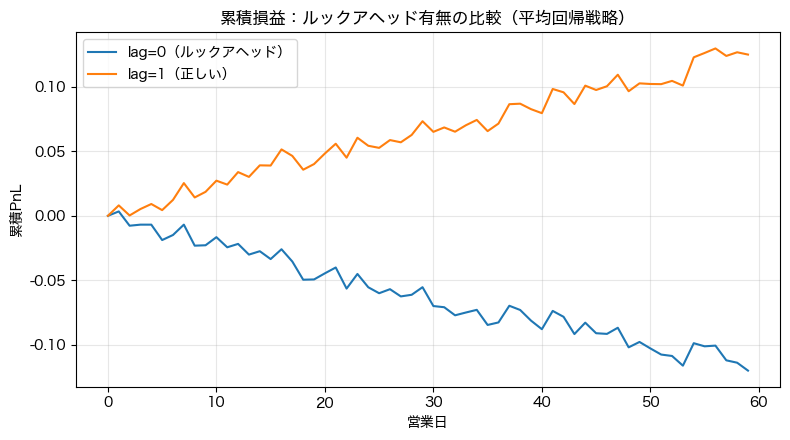

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for lag, label in [(0, "lag=0（ルックアヘッド）"), (1, "lag=1（正しい）")]:
    res = bt.backtest(sig_rv, ret_rv, cost_bps=0.0, lag=lag)
    ax.plot(res["pnl"].cumsum().values, label=label)
ax.set_title("累積損益：ルックアヘッド有無の比較（平均回帰戦略）")
ax.set_xlabel("営業日")
ax.set_ylabel("累積PnL")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 実データ適用

S9-1〜9-4 のシグナルとして、rich/cheap 平均回帰（40 銘柄）とバタフライ（2-5-10）を
統合し、単一のバックテストにまとめます。データは `data/samples` の合成 JGB
利回りパネルから作った rich/cheap 残差パネルです。最後にコスト感応度分析を
付けたレポートを出力します。

In [10]:
# 二戦略をひとつのシグナル/リターン行列に統合する。
signals_all = pd.concat([sig_rv, sig_fly], axis=1)
returns_all = pd.concat([ret_rv, ret_fly], axis=1).reindex_like(signals_all)
print("統合シグナル形状 (日付, 資産):", signals_all.shape)
print("内訳: rich/cheap {} 銘柄 + バタフライ 1 本".format(sig_rv.shape[1]))

# 個別戦略と統合戦略のパフォーマンス（コスト0.5bp, lag=1）。
report_rows = []
for name, s, r in [
    ("rich/cheap 平均回帰", sig_rv, ret_rv),
    ("バタフライ 2-5-10", sig_fly, ret_fly),
    ("統合", signals_all, returns_all),
]:
    res = bt.backtest(s, r, cost_bps=0.5, lag=1)
    perf = bt.performance(res["pnl"])
    report_rows.append({
        "戦略": name,
        "sharpe": perf["sharpe"],
        "ann_return": perf["ann_return"],
        "ann_vol": perf["ann_vol"],
        "max_drawdown": perf["max_drawdown"],
        "hit_rate": perf["hit_rate"],
        "平均回転率": res["turnover"].mean(),
    })
report = pd.DataFrame(report_rows).set_index("戦略")
print("\n=== 戦略別パフォーマンス（コスト0.5bp, lag=1）===")
display(report)

統合シグナル形状 (日付, 資産): (60, 41)
内訳: rich/cheap 40 銘柄 + バタフライ 1 本

=== 戦略別パフォーマンス（コスト0.5bp, lag=1）===


,sharpe,ann_return,ann_vol,max_drawdown,hit_rate,平均回転率
戦略,,,,,,
rich/cheap 平均回帰,3.836059,0.474958,0.123814,-0.016119,0.550000,3.971541
バタフライ 2-5-10,-9.971344,-0.096191,0.009647,-0.022903,0.116667,1.123925
統合,3.033971,0.378767,0.124842,-0.018433,0.533333,5.095466


### コスト感応度分析

統合戦略について、片道コストを 0〜5 bp で振り、シャープレシオと年率リターンが
どこで劣化するかを見ます。回転率が高い戦略ほどコストに脆いことが分かります。

In [11]:
cost_grid = np.array([0.0, 0.25, 0.5, 1.0, 2.0, 3.0, 5.0])
sens_rows = []
for c in cost_grid:
    res = bt.backtest(signals_all, returns_all, cost_bps=c, lag=1)
    perf = bt.performance(res["pnl"])
    sens_rows.append({"cost_bps": c, "sharpe": perf["sharpe"], "ann_return": perf["ann_return"]})
sens = pd.DataFrame(sens_rows).set_index("cost_bps")
display(sens)

# 損益分岐コスト（シャープが0を割る手前のコスト）を報告する。
positive = sens[sens["sharpe"] > 0]
if len(positive) < len(sens):
    breakeven = sens.index[sens["sharpe"] <= 0][0]
    print(f"\nシャープが0以下になる片道コスト: {breakeven} bp 付近")
else:
    print("\n試した範囲（〜5bp）ではシャープは正を維持")

,sharpe,ann_return
cost_bps,,
0.00,3.540114,0.442970
0.25,3.287575,0.410869
0.50,3.033971,0.378767
1.00,2.524001,0.314564
2.00,1.496129,0.186158
3.00,0.463792,0.057753
5.00,-1.584792,-0.199059



シャープが0以下になる片道コスト: 5.0 bp 付近


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


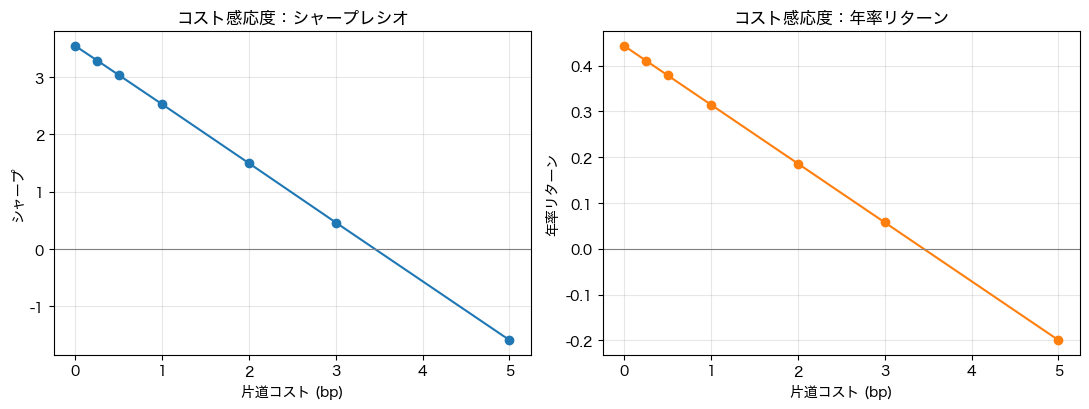

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(sens.index, sens["sharpe"], marker="o")
axes[0].axhline(0.0, color="gray", lw=0.8)
axes[0].set_title("コスト感応度：シャープレシオ")
axes[0].set_xlabel("片道コスト (bp)")
axes[0].set_ylabel("シャープ")
axes[0].grid(alpha=0.3)

axes[1].plot(sens.index, sens["ann_return"], marker="o", color="C1")
axes[1].axhline(0.0, color="gray", lw=0.8)
axes[1].set_title("コスト感応度：年率リターン")
axes[1].set_xlabel("片道コスト (bp)")
axes[1].set_ylabel("年率リターン")
axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

### 統合戦略の累積損益とドローダウン

コスト0.5bp・lag=1 での統合戦略の累積損益と、そこからのドローダウンを可視化します。

findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


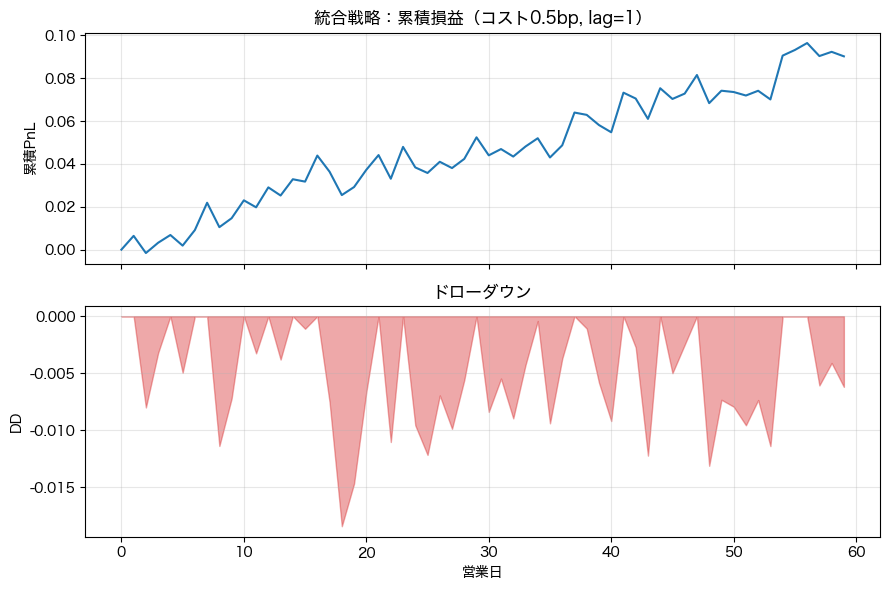

最大ドローダウン: -0.01843


In [13]:
res_final = bt.backtest(signals_all, returns_all, cost_bps=0.5, lag=1)
equity = res_final["pnl"].cumsum()
dd = equity - equity.cummax()

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(equity.values, color="C0")
axes[0].set_title("統合戦略：累積損益（コスト0.5bp, lag=1）")
axes[0].set_ylabel("累積PnL")
axes[0].grid(alpha=0.3)
axes[1].fill_between(range(len(dd)), dd.values, 0, color="C3", alpha=0.4)
axes[1].set_title("ドローダウン")
axes[1].set_xlabel("営業日")
axes[1].set_ylabel("DD")
axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

print("最大ドローダウン: {:.5f}".format(dd.min()))

## 演習

1. **取引コスト感応度**：統合戦略について、片道コストを 0〜10 bp まで細かく
   振り、シャープレシオが 1.0 を下回るコスト水準と、0 を下回るコスト水準
   （損益分岐）を求めよ。rich/cheap 単独・バタフライ単独・統合の3つで比べ、
   最もコストに脆いのはどれか、その理由を回転率と結びつけて述べよ。

2. **ルックアヘッドの成績差**：rich/cheap 戦略について、lag=0（同時点シグナル）・
   lag=1（翌日約定）・lag=2（2日遅延）でシャープ・年率リターン・最大ドローダウンを
   比較し、表にまとめよ。lag=0（誤り）が正しい lag=1 とどれだけ食い違うか、また
   lag=1→lag=2 で成績が下がることが「約定が遅れるほどシグナルの鮮度が落ちる」
   という直感と整合するかを論ぜよ。さらに、当日リターンを覗き見た反則シグナル
   $\operatorname{sign}(r_t)$ を lag=0 と lag=1 で比較し、過大評価の大きさを確認せよ。

解答例は `solutions/S9/sol_0905.py` に置きます。

## 用語集

定義の正は `glossary/09_trading.md`。ここでは初出語の一行要約のみ示します。

| 用語 | 英語 | 一行定義 |
|---|---|---|
| ルックアヘッドバイアス | look-ahead bias | 約定時点で知り得ない未来情報を使い、成績を過大評価する誤り |
| ポイントインタイム | point-in-time | 各時点で実際に見えていた値だけを使うデータの扱い |
| 最大ドローダウン | maximum drawdown | 累積損益が過去高値からどれだけ落ちたかの最悪値 |
| 過剰適合 | overfitting | パラメータ探索でノイズに当てはめ、将来再現しない戦略を作ること |